In [1]:
import matplotlib.pyplot as plt

%matplotlib inline
import numpy as np

from qiskit import QuantumCircuit
from qiskit_algorithms import IterativeAmplitudeEstimation, EstimationProblem
from qiskit.circuit.library import LinearAmplitudeFunction
from qiskit.primitives import StatevectorSampler
from qiskit_finance.circuit.library import LogNormalDistribution
from qiskit_finance.applications.estimation import EuropeanCallPricing, EuropeanCallDelta

# Pricing European Call

In [2]:
num_uncertainty_qubits = 3

S = 100
vol = 0.25
r = 0.045
T = 90/365

In [3]:
mu = (r - 0.5*vol**2) * T + np.log(S)
sigma = vol * np.sqrt(T)
mean = np.exp(mu + sigma**2 /2)
variance = (np.exp(sigma**2) - 1) * np.exp(2 * mu + sigma**2)
stddev = np.sqrt(variance)

In [4]:
low = np.maximum(0, mean - 3* stddev)
high = mean + 3 * stddev

In [5]:
uncertainty_model = LogNormalDistribution(
    num_uncertainty_qubits, mu=mu, sigma = sigma**2, bounds=(low, high)
)

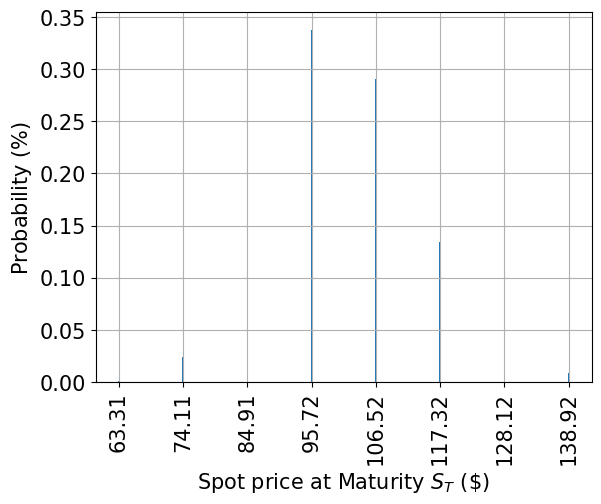

In [6]:
x = uncertainty_model.values
y = uncertainty_model.probabilities
plt.bar(x,y, width=0.2)
plt.xticks(x, size=15, rotation=90)
plt.yticks(size=15)
plt.grid()
plt.xlabel("Spot price at Maturity $S_T$ (\$)", size=15)
plt.ylabel("Probability ($\%$)", size=15)
plt.show()

In [7]:
K = 100

c_approx = 0.25

breakpoints = [low, K]
slopes = [0,1]
offsets = [0,0]
f_min = 0
f_max = high - K 
european_call_objective = LinearAmplitudeFunction(
    num_uncertainty_qubits, 
    slopes, 
    offsets,
    domain=(low, high),
    image=(f_min, f_max), 
    breakpoints=breakpoints, 
    rescaling_factor=c_approx
)

C:\Users\g.melis\AppData\Local\Temp\ipykernel_25456\14969661.py:10: DeprecationWarning: The class ``qiskit.circuit.library.arithmetic.linear_amplitude_function.LinearAmplitudeFunction`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the class qiskit.circuit.library.LinearAmplitudeFunctionGate instead.
  european_call_objective = LinearAmplitudeFunction(


In [8]:
num_qubits = european_call_objective.num_qubits
european_call = QuantumCircuit(num_qubits)
european_call.append(uncertainty_model, range(num_uncertainty_qubits))
european_call.append(european_call_objective, range(num_qubits))

european_call.draw()

┌───────┐┌────┐
q_0: ┤0      ├┤0   ├
     │       ││    │
q_1: ┤1 P(X) ├┤1   ├
     │       ││    │
q_2: ┤2      ├┤2   ├
     └───────┘│    │
q_3: ─────────┤3 F ├
              │    │
q_4: ─────────┤4   ├
              │    │
q_5: ─────────┤5   ├
              │    │
q_6: ─────────┤6   ├
              └────┘

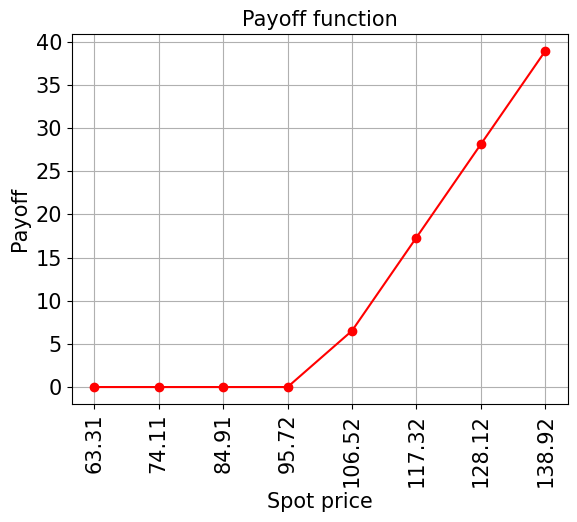

In [9]:
x = uncertainty_model.values
y = np.maximum(0, x - K)
plt.plot(x, y, "ro-")
plt.grid()
plt.title("Payoff function", size=15)
plt.xlabel("Spot price", size=15)
plt.ylabel("Payoff", size=15)
plt.xticks(x, size=15, rotation=90)
plt.yticks(size=15)
plt.show()

In [10]:
exact_value = np.dot(uncertainty_model.probabilities, y)
exact_delta = sum(uncertainty_model.probabilities[x >= K])
print("exact expected value :\t%.4f"% exact_value)
print("exact delta value :   \t%.4f"% exact_delta)

exact expected value :	5.6291
exact delta value :   	0.4719


In [11]:
epsilon = 0.01
alpha = 0.05

problem = EstimationProblem(
    state_preparation=european_call,
    objective_qubits=[3],
    post_processing=european_call_objective.post_processing,
)

# Qiskit 1.x : StatevectorSampler au lieu de Sampler
sampler = StatevectorSampler()

ae = IterativeAmplitudeEstimation(
    epsilon_target=epsilon,
    alpha=alpha,
    sampler=sampler
)

In [12]:
result = ae.estimate(problem)

In [13]:
conf_int = np.array(result.confidence_interval_processed)
print("Exact value:        \t%.4f" % exact_value)
print("Estimated value:    \t%.4f" % (result.estimation_processed))
print("Confidence interval:\t[%.4f, %.4f]" % tuple(conf_int))

Exact value:        	5.6291
Estimated value:    	6.1178
Confidence interval:	[5.7491, 6.4865]


In [14]:
european_call_pricing = EuropeanCallPricing(
    num_state_qubits=num_uncertainty_qubits,
    strike_price=K,
    rescaling_factor=c_approx,
    bounds=(low, high),
    uncertainty_model=uncertainty_model,
)

In [15]:
epsilon = 0.01
alpha = 0.05

sampler = StatevectorSampler()

problem = european_call_pricing.to_estimation_problem()
# construct amplitude estimation
ae = IterativeAmplitudeEstimation(
    epsilon_target=epsilon,
    alpha=alpha,
    sampler=sampler
)
result = ae.estimate(problem)

conf_int = np.array(result.confidence_interval_processed)
print("Exact value:        \t%.4f" % exact_value)
print("Estimated value:    \t%.4f" % (european_call_pricing.interpret(result)))
print("Confidence interval:\t[%.4f, %.4f]" % tuple(conf_int))

Exact value:        	5.6291
Estimated value:    	6.0065
Confidence interval:	[5.6945, 6.3186]


In [16]:
european_call_delta = EuropeanCallDelta(
    num_state_qubits=num_uncertainty_qubits,
    strike_price=K,
    bounds=(low, high),
    uncertainty_model=uncertainty_model,
)

In [17]:
european_call_delta._objective.decompose().draw()

┌──────────────┐
state_0: ┤0             ├
         │              │
state_1: ┤1             ├
         │              │
state_2: ┤2             ├
         │  circuit-418 │
state_3: ┤3             ├
         │              │
 work_0: ┤4             ├
         │              │
 work_1: ┤5             ├
         └──────────────┘

In [18]:
european_call_delta_circ = QuantumCircuit(european_call_delta._objective.num_qubits)
european_call_delta_circ.append(uncertainty_model, range(num_uncertainty_qubits))
european_call_delta_circ.append(
    european_call_delta._objective, range(european_call_delta._objective.num_qubits)
)

european_call_delta_circ.draw()

┌───────┐┌──────┐
q_0: ┤0      ├┤0     ├
     │       ││      │
q_1: ┤1 P(X) ├┤1     ├
     │       ││      │
q_2: ┤2      ├┤2     ├
     └───────┘│  ECD │
q_3: ─────────┤3     ├
              │      │
q_4: ─────────┤4     ├
              │      │
q_5: ─────────┤5     ├
              └──────┘

In [19]:
# set target precision and confidence level
epsilon = 0.01
alpha = 0.05

problem = european_call_delta.to_estimation_problem()

sampler = StatevectorSampler()

# construct amplitude estimation
ae_delta = IterativeAmplitudeEstimation(
    epsilon_target=epsilon, alpha=alpha, sampler=sampler)


In [20]:
result_delta = ae_delta.estimate(problem)

In [21]:
conf_int = np.array(result_delta.confidence_interval_processed)
print("Exact delta:    \t%.4f" % exact_delta)
print("Estimated value: \t%.4f" % european_call_delta.interpret(result_delta))
print("Confidence interval: \t[%.4f, %.4f]" % tuple(conf_int))

Exact delta:    	0.4719
Estimated value: 	0.4718
Confidence interval: 	[0.4680, 0.4757]


In [22]:
from utils import bs_call

european_call_exact = bs_call(100, 100, 0.25, 0.045, 90/365)
print(european_call_exact)

5.493370072121898


# Pricing European Put

In [23]:
K = 90

In [24]:
from utils import bs_put

print(bs_put(100, K, 0.25, 0.045, 90/365))

1.095032439491991


In [25]:
rescaling_factor = 0.25

# setup piecewise linear objective fcuntion
breakpoints = [low, K]
slopes = [-1, 0]
offsets = [K - low, 0]
f_min = 0
f_max = K - low
european_put_objective = LinearAmplitudeFunction(
    num_uncertainty_qubits,
    slopes,
    offsets,
    domain=(low, high),
    image=(f_min, f_max),
    breakpoints=breakpoints,
    rescaling_factor=rescaling_factor,
)

# construct A operator for QAE for the payoff function by
# composing the uncertainty model and the objective
european_put = european_put_objective.compose(uncertainty_model, front=True)

C:\Users\g.melis\AppData\Local\Temp\ipykernel_25456\4283208417.py:9: DeprecationWarning: The class ``qiskit.circuit.library.arithmetic.linear_amplitude_function.LinearAmplitudeFunction`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the class qiskit.circuit.library.LinearAmplitudeFunctionGate instead.
  european_put_objective = LinearAmplitudeFunction(


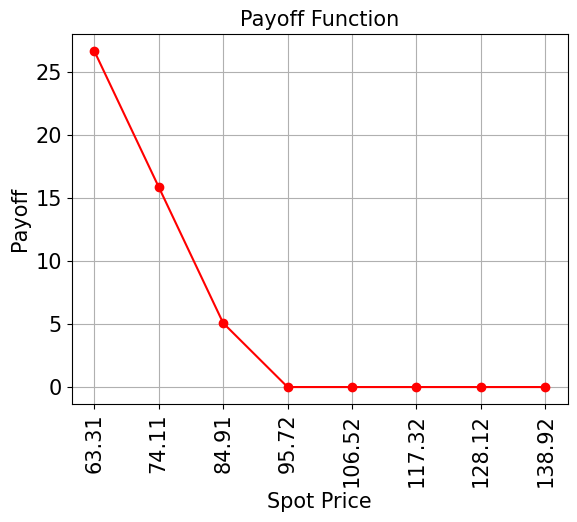

In [26]:
x = uncertainty_model.values
y = np.maximum(0, K - x)
plt.plot(x, y, "ro-")
plt.grid()
plt.title("Payoff Function", size=15)
plt.xlabel("Spot Price", size=15)
plt.ylabel("Payoff", size=15)
plt.xticks(x, size=15, rotation=90)
plt.yticks(size=15)
plt.show()

In [27]:
exact_value = np.dot(uncertainty_model.probabilities, y)
exact_delta = -sum(uncertainty_model.probabilities[x <= K])
print("exact expected value:\t%.4f" % exact_value)
print("exact delta value:   \t%.4f" % exact_delta)

exact expected value:	1.2374
exact delta value:   	-0.1902


In [28]:
epsilon = 0.01
alpha = 0.05

problem = EstimationProblem(
    state_preparation=european_put,
    objective_qubits=[num_uncertainty_qubits],
    post_processing=european_put_objective.post_processing,
)

sampler = StatevectorSampler()
# construct amplitude estimation
ae = IterativeAmplitudeEstimation(
    epsilon_target=epsilon, alpha=alpha, sampler=sampler
)

In [29]:
result = ae.estimate(problem)

In [30]:
conf_int = np.array(result.confidence_interval_processed)
print("Exact value:        \t%.4f" % exact_value)
print("Estimated value:    \t%.4f" % (result.estimation_processed))
print("Confidence interval:\t[%.4f, %.4f]" % tuple(conf_int))

Exact value:        	1.2374
Estimated value:    	1.5290
Confidence interval:	[1.2282, 1.8298]


In [31]:
breakpoints = [low, K]
slopes = [0, 0]
offsets = [1, 0]
f_min = 0
f_max = 1

european_put_delta_objective = LinearAmplitudeFunction(
    num_uncertainty_qubits,
    slopes,
    offsets,
    domain=(low, high),
    image=(f_min, f_max),
    breakpoints=breakpoints,
)

# construct circuit for payoff function
european_put_delta = european_put_delta_objective.compose(uncertainty_model, front=True)

C:\Users\g.melis\AppData\Local\Temp\ipykernel_25456\1261161226.py:7: DeprecationWarning: The class ``qiskit.circuit.library.arithmetic.linear_amplitude_function.LinearAmplitudeFunction`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the class qiskit.circuit.library.LinearAmplitudeFunctionGate instead.
  european_put_delta_objective = LinearAmplitudeFunction(


In [32]:
epsilon = 0.01
alpha = 0.05

problem = EstimationProblem(
    state_preparation=european_put_delta, objective_qubits=[num_uncertainty_qubits]
)

sampler = StatevectorSampler()
ae_delta = IterativeAmplitudeEstimation(
    epsilon_target=epsilon, alpha=alpha, sampler=sampler
)

In [33]:
result_delta = ae_delta.estimate(problem)

In [34]:
conf_int = -np.array(result_delta.confidence_interval)[::-1]
print("Exact delta:    \t%.4f" % exact_delta)
print("Estimated value: \t%.4f" % -result_delta.estimation)
print("Confidence interval: \t[%.4f, %.4f]" % tuple(conf_int))

Exact delta:    	-0.1902
Estimated value: 	-0.1905
Confidence interval: 	[-0.1942, -0.1868]
